In [1]:
# Auditable EU AI Act KG build (regex-only explicit cross-references)
import pandas as pd
from pathlib import Path

KG_PYTHON = "/opt/anaconda3/envs/ml_env/bin/python"
GRAPHSAGE_PYTHON = "/opt/anaconda3/envs/graphsage_tf1/bin/python"
TSV_PATH = Path("EU_AI_ACT_articles_paragraphs_annexes.tsv")
OUTDIR = Path("kg_out")
print("KG python:", KG_PYTHON)
print("GraphSAGE python:", GRAPHSAGE_PYTHON)
print(TSV_PATH, "exists=", TSV_PATH.exists())
print("Output dir:", OUTDIR)


KG python: /opt/anaconda3/envs/ml_env/bin/python
EU_AI_ACT_articles_paragraphs_annexes.tsv exists= True
Output dir: kg_out


In [2]:
import subprocess

cmd = [KG_PYTHON, "build_kg.py", "--tsv", str(TSV_PATH), "--outdir", str(OUTDIR)]
result = subprocess.run(cmd, capture_output=True, text=True, check=True)
print(result.stdout)
if result.stderr.strip():
    print(result.stderr)


Duplicate locators merged: 20
Annex stub nodes added: 0
Contains edges: 584
Refers_to edges: 485
Top 10 most cited articles (in-degree):
  Article 5: 20
  Article 47: 14
  Article 6: 13
  Article 97: 13
  Article 78: 13
  Article 49: 12
  Article 43: 12
  Article 11: 12
  Article 31: 12
  Article 98: 11
Top 10 articles citing others most (article-level out-degree):
  Article 2: 14
  Article 74: 14
  Article 96: 12
  Article 26: 11
  Article 99: 11
  Article 63: 10
  Article 66: 10
  Article 16: 8
  Article 49: 8
  Article 60: 8
Wrote nodes.csv, edges.csv, edges.parquet, node_embeddings.parquet, graph_summary.json to kg_out

/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be 

In [3]:
embeddings = pd.read_parquet("kg_out/node_embeddings.parquet")
embeddings.head()


,node_id,embedding
0,Article 1,"[0.057433463633060455, 0.007909460924565792, -..."
1,Article 1(1),"[-0.020804326981306076, 0.008519789204001427, ..."
2,Article 1(2),"[-0.030288847163319588, -0.08144176006317139, ..."
3,Article 2,"[0.009632343426346779, 0.038962576538324356, -..."
4,Article 2(1),"[0.0046546682715415955, -0.08178311586380005, ..."


In [4]:
from pathlib import Path
import json
import pandas as pd

outdir = Path("kg_out")
nodes_file = outdir / "nodes.parquet" if (outdir / "nodes.parquet").exists() else outdir / "nodes.csv"
edges_file = outdir / "edges.parquet" if (outdir / "edges.parquet").exists() else outdir / "edges.csv"

nodes = pd.read_parquet(nodes_file) if nodes_file.suffix == ".parquet" else pd.read_csv(nodes_file)
edges = pd.read_parquet(edges_file) if edges_file.suffix == ".parquet" else pd.read_csv(edges_file)
summary = json.loads((outdir / "graph_summary.json").read_text())

print("nodes:", nodes.shape, "edges:", edges.shape)
print(summary["edge_counts_by_rel"])
display(nodes.head(5))
display(edges[edges["rel"] == "REFERS_TO"].head(10))
display(summary["sample_edges"][:5])


nodes: (710, 4) edges: (1069, 6)
{'CONTAINS': 584, 'REFERS_TO': 485}


,node_id,kind,text,seq
0,Article 1,ARTICLE,Subject matter,0
1,Article 1(1),PARAGRAPH,The purpose of this Regulation is to improve t...,1
2,Article 1(2),PARAGRAPH,This Regulation lays down: (a) harmonised rule...,2
3,Article 2,ARTICLE,Scope,3
4,Article 2(1),PARAGRAPH,This Regulation applies to: (a) providers plac...,4


,src,rel,dst,evidence_span,evidence_text,confidence
584,Article 2(2),REFERS_TO,Article 6,Article 6(1),classified as high-risk AI systems in accordan...,1.0
585,Article 2(2),REFERS_TO,ANNEX I,Annex I,Union harmonisation legislation listed in Sect...,1.0
586,Article 2(2),REFERS_TO,Article 102,Articles 102 to 109,"isted in Section B of Annex I, only Article 6(...",1.0
587,Article 2(2),REFERS_TO,Article 103,Articles 102 to 109,"isted in Section B of Annex I, only Article 6(...",1.0
588,Article 2(2),REFERS_TO,Article 104,Articles 102 to 109,"isted in Section B of Annex I, only Article 6(...",1.0
589,Article 2(2),REFERS_TO,Article 105,Articles 102 to 109,"isted in Section B of Annex I, only Article 6(...",1.0
590,Article 2(2),REFERS_TO,Article 106,Articles 102 to 109,"isted in Section B of Annex I, only Article 6(...",1.0
591,Article 2(2),REFERS_TO,Article 107,Articles 102 to 109,"isted in Section B of Annex I, only Article 6(...",1.0
592,Article 2(2),REFERS_TO,Article 108,Articles 102 to 109,"isted in Section B of Annex I, only Article 6(...",1.0
593,Article 2(2),REFERS_TO,Article 109,Articles 102 to 109,"isted in Section B of Annex I, only Article 6(...",1.0


[{'src': 'Article 2(2)',
  'rel': 'REFERS_TO',
  'dst': 'Article 6',
  'evidence_span': 'Article 6(1)',
  'evidence_text': 'classified as high-risk AI systems in accordance with Article 6(1) related to products covered by the Union harmonisatio',
  'confidence': 1.0},
 {'src': 'Article 2(2)',
  'rel': 'REFERS_TO',
  'dst': 'ANNEX I',
  'evidence_span': 'Annex I',
  'evidence_text': 'Union harmonisation legislation listed in Section B of Annex I, only Article 6(1), Articles 102 to 109 and Article 112',
  'confidence': 1.0},
 {'src': 'Article 2(2)',
  'rel': 'REFERS_TO',
  'dst': 'Article 102',
  'evidence_span': 'Articles 102 to 109',
  'evidence_text': 'isted in Section B of Annex I, only Article 6(1), Articles 102 to 109 and Article 112 apply. Article 57 applies only in',
  'confidence': 1.0},
 {'src': 'Article 2(2)',
  'rel': 'REFERS_TO',
  'dst': 'Article 103',
  'evidence_span': 'Articles 102 to 109',
  'evidence_text': 'isted in Section B of Annex I, only Article 6(1), Articles 10

In [5]:
import numpy as np
import pandas as pd
import subprocess
from pathlib import Path

train_model = "gcn"
train_model_size = "small"
train_lr = 0.0001

train_cmd = [
    GRAPHSAGE_PYTHON,
    "unsupervised_train.py",
    "--model", train_model,
    "--epochs", "1000",
    "--print_every", "100",
    "--embedding_path", str(OUTDIR / "node_embeddings.parquet"),
    "--edge_path", str(OUTDIR / "edges.parquet"),
    "--base_log_dir", str(OUTDIR),
]
train_result = subprocess.run(train_cmd, capture_output=True, text=True, check=True)
print(train_result.stdout)
if train_result.stderr.strip():
    print(train_result.stderr)


Loading training data..
Done loading training data..
Unexpected missing: 0
710 train nodes
0 test nodes
Epoch: 0001
Iter: 0000 train_loss= 22.24527 train_mrr= 0.62637 train_mrr_ema= 0.62637 val_loss= nan val_mrr= nan val_mrr_ema= nan time= 1.19828
Epoch: 0002
Epoch: 0003
Epoch: 0004
Epoch: 0005
Epoch: 0006
Epoch: 0007
Epoch: 0008
Epoch: 0009
Epoch: 0010
Epoch: 0011
Epoch: 0012
Epoch: 0013
Epoch: 0014
Epoch: 0015
Epoch: 0016
Epoch: 0017
Epoch: 0018
Epoch: 0019
Epoch: 0020
Epoch: 0021
Epoch: 0022
Epoch: 0023
Epoch: 0024
Epoch: 0025
Epoch: 0026
Epoch: 0027
Epoch: 0028
Epoch: 0029
Epoch: 0030
Epoch: 0031
Epoch: 0032
Epoch: 0033
Epoch: 0034
Iter: 0001 train_loss= 19.58713 train_mrr= 0.64302 train_mrr_ema= 0.62477 val_loss= nan val_mrr= nan val_mrr_ema= nan time= 0.45090
Epoch: 0035
Epoch: 0036
Epoch: 0037
Epoch: 0038
Epoch: 0039
Epoch: 0040
Epoch: 0041
Epoch: 0042
Epoch: 0043
Epoch: 0044
Epoch: 0045
Epoch: 0046
Epoch: 0047
Epoch: 0048
Epoch: 0049
Epoch: 0050
Epoch: 0051
Epoch: 0052
Epoch: 0

In [6]:
train_outdir = OUTDIR / "unsup-node_embeddings" / f"{train_model}_{train_model_size}_{train_lr:0.6f}"
train_nodes_path = train_outdir / "train.txt"
train_embeds_path = train_outdir / "train.npy"
if not train_nodes_path.exists():
    train_nodes_path = train_outdir / "val.txt"
    train_embeds_path = train_outdir / "val.npy"
train_nodes = train_nodes_path.read_text().splitlines()
train_embeds = np.load(train_embeds_path)
pd.DataFrame({"node_id": train_nodes, "embedding": list(train_embeds)}).head()

,node_id,embedding
0,Article 67(5),"[0.07250653, 0.0033072927, 0.072241195, 0.0199..."
1,Article 2(8),"[0.06271983, 0.12040089, -0.0027377107, 0.0284..."
2,Article 3(25),"[0.14841777, 0.110163204, 0.006138568, -0.0107..."
3,Article 98,"[-0.11170369, 0.11176302, -0.0014434967, -0.08..."
4,Article 7,"[-0.045853823, -0.011168423, -0.061022986, -0...."


In [7]:
f"{train_lr:0.6f}"

'0.000100'

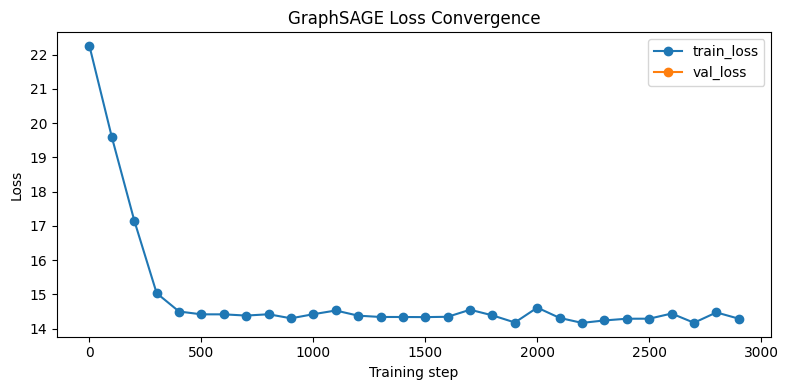

PosixPath('kg_out/unsup-node_embeddings/gcn_small_0.000100/loss_convergence.png')

In [8]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

matches = re.findall(r"train_loss=\s*([0-9.]+).*val_loss=\s*([A-Za-z0-9.+-]+)", train_result.stdout)
loss_curve = pd.DataFrame(
    {
        "step": np.arange(len(matches)) * 100,
        "train_loss": [float(train_loss) for train_loss, _ in matches],
        "val_loss": [float(val_loss) for _, val_loss in matches],
    }
)

ax = loss_curve.plot(x="step", y=["train_loss", "val_loss"], marker="o", figsize=(8, 4))
ax.set_title("GraphSAGE Loss Convergence")
ax.set_xlabel("Training step")
ax.set_ylabel("Loss")
ax.figure.tight_layout()
plot_path = train_outdir / "loss_convergence.png"
ax.figure.savefig(plot_path, dpi=150)
plt.show()
plot_path


In [9]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.decomposition import PCA

common_ids = embeddings["node_id"][embeddings["node_id"].isin(train_nodes)].tolist()
node_meta = nodes[["node_id", "kind"]].drop_duplicates()
node_degree = pd.concat([edges["src"], edges["dst"]]).value_counts().rename("degree")

raw_frame = embeddings.drop_duplicates("node_id").set_index("node_id").loc[common_ids].reset_index()
raw_frame = raw_frame.merge(node_meta, on="node_id", how="left")
raw_frame = raw_frame.merge(node_degree, left_on="node_id", right_index=True, how="left")

trained_frame = pd.DataFrame({"node_id": train_nodes, "embedding": list(train_embeds)})
trained_frame = trained_frame.drop_duplicates("node_id").set_index("node_id").loc[common_ids].reset_index()
trained_frame = trained_frame.merge(node_meta, on="node_id", how="left")
trained_frame = trained_frame.merge(node_degree, left_on="node_id", right_index=True, how="left")

for frame in (raw_frame, trained_frame):
    frame["kind"] = frame["kind"].fillna("UNKNOWN")
    frame["degree"] = frame["degree"].fillna(0)

label_nodes = raw_frame.sort_values("degree", ascending=False).head(12)["node_id"].tolist()
palette = {
    "ARTICLE": "#1f77b4",
    "PARAGRAPH": "#ff7f0e",
    "ANNEX": "#2ca02c",
    "UNKNOWN": "#7f7f7f",
}

def project_embeddings(frame, title):
    matrix = np.vstack(frame["embedding"].map(np.asarray))
    pca = PCA(n_components=3, random_state=0)
    coords = pca.fit_transform(matrix)
    plot_frame = frame.assign(pc1=coords[:, 0], pc2=coords[:, 1], pc3=coords[:, 2])
    explained = pca.explained_variance_ratio_.sum()
    traces = []

    for kind, group in plot_frame.groupby("kind"):
        traces.append(
            go.Scatter3d(
                x=group["pc1"],
                y=group["pc2"],
                z=group["pc3"],
                mode="markers+text",
                name=kind,
                legendgroup=kind,
                marker={"size": 4, "opacity": 0.75, "color": palette.get(kind, palette["UNKNOWN"])} ,
                text=np.where(group["node_id"].isin(label_nodes), group["node_id"], ""),
                textposition="top center",
                customdata=group[["node_id", "kind", "degree"]].to_numpy(),
                hovertemplate=(
                    "node_id=%{customdata[0]}<br>kind=%{customdata[1]}<br>degree=%{customdata[2]}"
                    "<br>PC1=%{x:.3f}<br>PC2=%{y:.3f}<br>PC3=%{z:.3f}<extra></extra>"
                ),
                showlegend=False,
            )
        )

    subplot_title = f"{title}<br><sup>PCA variance explained: {explained:.1%}</sup>"
    return plot_frame, traces, subplot_title

raw_plot, raw_traces, raw_title = project_embeddings(raw_frame, "Raw KG embeddings")
trained_plot, trained_traces, trained_title = project_embeddings(trained_frame, f"{train_model.upper()}-trained embeddings")

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "scene"}, {"type": "scene"}]],
    subplot_titles=[raw_title, trained_title],
    horizontal_spacing=0.03,
)

for trace in raw_traces:
    trace.showlegend = True
    fig.add_trace(trace, row=1, col=1)

for trace in trained_traces:
    fig.add_trace(trace, row=1, col=2)

scene_layout = {
    "xaxis_title": "PC 1",
    "yaxis_title": "PC 2",
    "zaxis_title": "PC 3",
    "camera": {"eye": {"x": 1.5, "y": 1.5, "z": 0.9}},
}
fig.update_layout(
    title=f"Node embedding projections for {len(common_ids)} KG nodes",
    height=750,
    width=1500,
    legend={"orientation": "h", "yanchor": "bottom", "y": 1.02, "xanchor": "center", "x": 0.5},
    margin={"l": 0, "r": 0, "t": 90, "b": 0},
    scene=scene_layout,
    scene2=scene_layout,
)

projection_path = train_outdir / f"{train_model}_embedding_projection_3d.html"
fig.write_html(projection_path, include_plotlyjs="cdn")
fig.show()
projection_path


PosixPath('kg_out/unsup-node_embeddings/gcn_small_0.000100/gcn_embedding_projection_3d.html')

In [19]:
import json
import numpy as np
import pandas as pd
import subprocess
import torch
import torch.nn.functional as F
from gnn_retriever import load_gnn_model

query = "What type of Systems are regulated under the AI act?"
query_cmd = [
    KG_PYTHON,
    "-c",
    (
        "import json, sys; "
        "from sentence_transformers import SentenceTransformer; "
        "model = SentenceTransformer('all-MiniLM-L6-v2'); "
        "print(json.dumps(model.encode(sys.argv[1], normalize_embeddings=True).tolist()))"
    ),
    query,
]
query_emb = torch.tensor(json.loads(subprocess.run(query_cmd, capture_output=True, text=True, check=True).stdout), dtype=torch.float32)

node_ids = train_nodes
node_to_idx = {node_id: i for i, node_id in enumerate(node_ids)}
pairs = [
    (node_to_idx[src], node_to_idx[dst])
    for src, dst in edges[["src", "dst"]].itertuples(index=False, name=None)
    if src in node_to_idx and dst in node_to_idx
]
edge_index = torch.tensor(pairs, dtype=torch.long).t().contiguous() if pairs else torch.empty((2, 0), dtype=torch.long)
if edge_index.numel():
    edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)

x = torch.tensor(np.asarray(train_embeds), dtype=torch.float32)
model = load_gnn_model["gcn"](x.size(1), x.size(1), query_emb.numel(), num_layers=2, dropout=0.0)
model.eval()

with torch.no_grad():
    gnn_emb, _ = model(x, edge_index, None)

scores = torch.mv(F.normalize(gnn_emb, dim=1), query_emb)
topk = torch.topk(scores, k=min(5, scores.numel()))
results = pd.DataFrame(
    {
        "rank": range(1, len(topk.indices) + 1),
        "node_id": [node_ids[idx] for idx in topk.indices.tolist()],
        "score": topk.values.tolist(),
    }
)
retrieved_nodes = results.merge(nodes[["node_id", "kind", "text"]], on="node_id", how="left")
retrieved_edges = edges[
    edges["src"].isin(retrieved_nodes["node_id"]) | edges["dst"].isin(retrieved_nodes["node_id"])
][["src", "rel", "dst", "confidence"]]
display(retrieved_nodes)
display(retrieved_edges)


/opt/anaconda3/envs/graphsage_tf1/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,rank,node_id,score,kind,text
0,1,Article 59,0.026025,ARTICLE,Further processing of personal data for develo...
1,2,Article 59(3),0.024823,PARAGRAPH,Paragraph 1 is without prejudice to Union or n...
2,3,Article 59(2),0.024568,PARAGRAPH,"For the purposes of the prevention, investigat..."
3,4,Article 35,0.016348,ARTICLE,Identification numbers and lists of notified b...
4,5,Article 59(1),0.015909,PARAGRAPH,"In the AI regulatory sandbox, personal data la..."


,src,rel,dst,confidence
226,Article 35,CONTAINS,Article 35(1),1.0
227,Article 35,CONTAINS,Article 35(2),1.0
352,Article 59,CONTAINS,Article 59(1),1.0
353,Article 59,CONTAINS,Article 59(2),1.0
354,Article 59,CONTAINS,Article 59(3),1.0
597,Article 2(7),REFERS_TO,Article 59,1.0
694,Article 26(9),REFERS_TO,Article 35,1.0
705,Article 27(4),REFERS_TO,Article 35,1.0
781,Article 49(5),REFERS_TO,Article 35,1.0
815,Article 59(1),REFERS_TO,Article 35,1.0


In [10]:
import torch_geometric
print(torch_geometric.__version__)

2.3.1
